
## How to Use the Notebooks

To run these notebooks, follow these steps:


### 1. Install **`gdal`** Package
Installing `gdal` via `pip` may fail. Therefore, we recommend using conda to install it:
```bash
conda install gdal -c conda-forge
```

### 2. Install **`polsartools`** Package

Before running the notebooks, you'll need to install the core **`polsartools`** package. 

**Option A:** Install from PyPI `pip` (stable release)

```bash
pip install polsartools
```

**Option B:** Install from conda (stable release)

```bash
conda install polsartools -c bnarayanarao
```


**Option C:**  Install the latest version from GitHub (if you need recent updates or fixes)

```bash
pip install git+https://github.com/Narayana-Rao/polsartools.git#egg=polsartools
```
> **Note:** If you encounter a `"module not found"` error or require newer features, prefer the **Option C**.

### 3. Verify the Installation

After successfully installing `polsartools`, you can verify it by importing the package:

```bash
import polsartools as pst
```

If this runs without errors, you're ready to explore and run the notebooks.




In [1]:
import polsartools as pst
import os
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np


In [2]:
""" 

Function to display images

"""

def plot_images(*filenames, lower_percentile=2, upper_percentile=98, max_cols=4):
    def compute_vmin_vmax(data):
        data_no_nan = data[np.isfinite(data)]
        vmin = np.percentile(data_no_nan, lower_percentile)
        vmax = np.percentile(data_no_nan, upper_percentile)
        return vmin, vmax

    num_images = len(filenames)

    if num_images == 1:
        # Single image case
        data = pst.read_rst(filenames[0])
        data[data==0]=np.nan
        vmin, vmax = compute_vmin_vmax(data)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(data, vmin=vmin, vmax=vmax)
        ax.set_title(os.path.basename(filenames[0]))
        fig.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        # Multiple image case
        ncols = min(max_cols, num_images)
        nrows = int(np.ceil(num_images / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
        axes = np.array(axes).reshape(-1)  # Flatten in case it's a 2D grid

        for i, filename in enumerate(filenames):
            data = pst.read_rst(filename)
            data[data==0]=np.nan
            vmin, vmax = compute_vmin_vmax(data)
            ax = axes[i]
            im = ax.imshow(data, vmin=vmin, vmax=vmax)
            ax.set_title(os.path.basename(filename))
            fig.colorbar(im, ax=ax)

        for j in range(num_images, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()


#### Extract multilooked C2 matrix elements

In [3]:
# Provide path to the extracted folder
in_dir = r"./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32"

#The follwoing function extracts single look Sxy or mulit-looked C2 matrix from Chandrayaan-II CP data

pst.chyaan2_cp(in_dir,mat='C2')


Progress: 100%|███████████████████████████████████████████████████████████████| 310/310 [00:00<00:00, 373.19block/s]


Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/C2/C11.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/C2/C12_real.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/C2/C12_imag.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/C2/C22.tif
Execution time for convert_S: 1.00 seconds
Execution time for chyaan2_cp: 4.00 seconds


#### Speckle filtering using polarimetric refined-Lee filter

In [4]:
"""
The following function generates speckel filtered polarimetric matrices using refined lee polarimetric speckle filter: 
        
input C3/T3/C2/T2 folder path, window_size between 3-31  

"""

c2Folder = os.path.join(in_dir,'C2')
window_size = 3
pst.rlee(c2Folder,win=window_size)

Progress: 100%|██████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 24.72block/s]


Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/C11.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/C12_real.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/C12_imag.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/C22.tif
Execution time for rlee: 1.00 seconds


#### Generate a quick look RGB

RGB image saved as ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/RGB3.png
Execution time for dxpRGB: 1.00 seconds


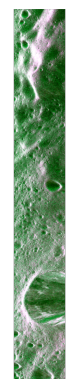

In [5]:
# update the C2 folder based on your folder
c2Folder = os.path.join(in_dir,'rlee_3x3','C2') 

pst.dxpRGB(c2Folder,type=3) # type supports 1,2,3,4


#### Generate Degree of polarization (DoP)

In [6]:
pst.dop_cp(c2Folder,win=5)

Progress: 100%|██████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 73.89block/s]


Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/dopcp.tif
Execution time for dop_cp: 0.00 seconds


#### Display Degree of polarization (DoP) 

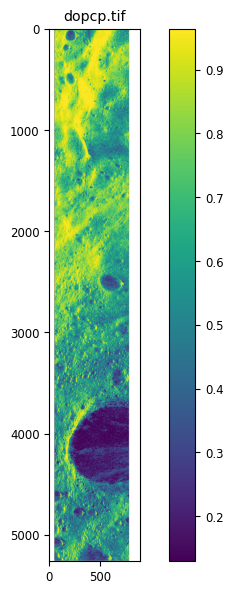

In [7]:

plot_images(os.path.join(c2Folder,'dopcp.tif'))


#### Generate Model-free 3-component decomposition powers

In [8]:
pst.mf3cc(c2Folder,win=5)

Progress: 100%|██████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 40.26block/s]


Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/Ps_mf3cc.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/Pd_mf3cc.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/Pv_mf3cc.tif
Saved file ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/Theta_CP_mf3cc.tif
Execution time for mf3cc: 0.00 seconds


#### Display decomposed powers and scattering type parameter

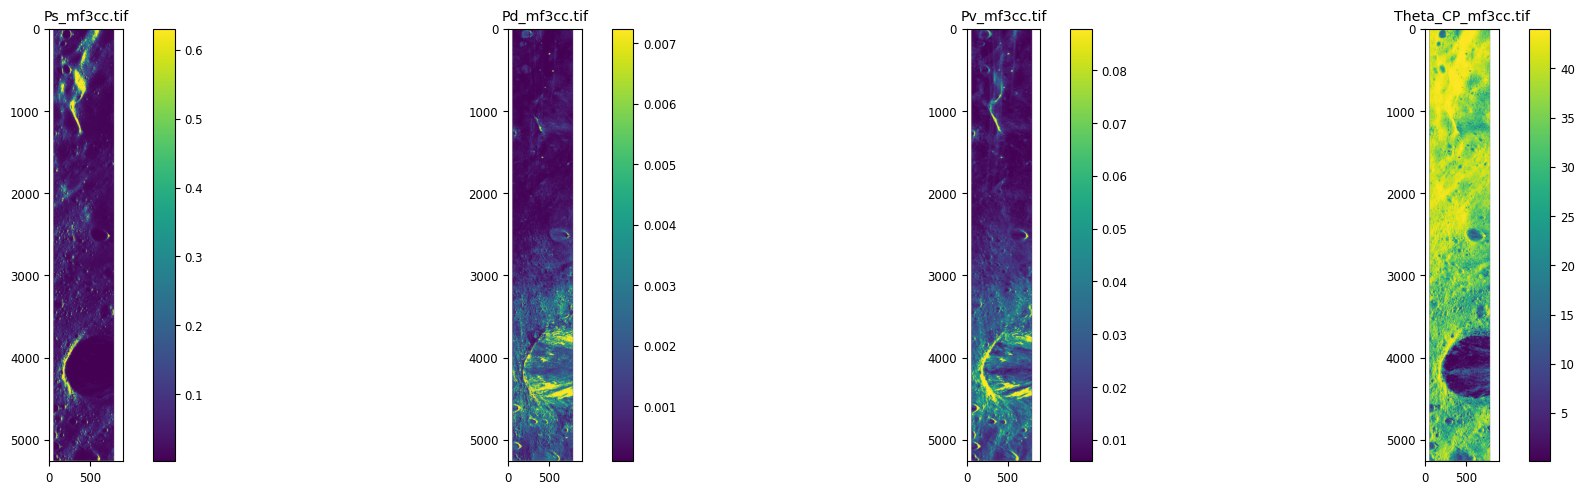

In [9]:


plot_images(os.path.join(c2Folder,'Ps_mf3cc.tif'),
            os.path.join(c2Folder,'Pd_mf3cc.tif'),
            os.path.join(c2Folder,'Pv_mf3cc.tif'),
            os.path.join(c2Folder,'Theta_CP_mf3cc.tif'),
           )



#### Create False colour RGB from decomposed powers

RGB image saved as ./data/ch2_sar_ncxl_20230620t104248387_d_cp_d32/rlee_3x3/C2/RGB.png
Execution time for rgb: 2.00 seconds


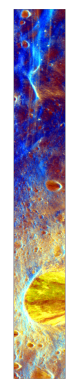

In [10]:


blue = os.path.join(c2Folder,'Ps_mf3cc.tif')
red = os.path.join(c2Folder,'Pd_mf3cc.tif')
green = os.path.join(c2Folder,'Pv_mf3cc.tif')

pst.rgb(red,green,blue)
